# Regression from Scratch v3 (NumPy only) — Income, 3/3-only ablation

**Version:** 3rd Version (feature ablation). **Role:** primary deliverable. Pure-NumPy twin of `regression_pytorch_v3.ipynb`.

**What changed vs v2:** features only — 3/3 consensus (8 cols, all numeric → 8 dims). Dropped 2/3: NumStorePurchases, MntFishProducts, Kidhome, Age, NumDealsPurchases. Same ResNet arch (in_dim=8), Adam+cosine+wd, 100 epochs, z-scored target. Weights → `./weights_v3/regression_scratch.npz`.

In [1]:
import json
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

SEED = 42
np.random.seed(SEED)
os.makedirs("weights_v3", exist_ok=True)

# ---- 1. LOAD DATA (3/3 features only) ----
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df = df.drop(columns=["ID", "Z_CostContact", "Z_Revenue"])
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
ref_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (ref_date - df["Dt_Customer"]).dt.days
df["Age"] = 2014 - df["Year_Birth"]
df = df[~df["Year_Birth"].isin([1893, 1899, 1900])].copy()
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})
df = df.dropna(subset=["Income"]).copy()
print("cleaned:", df.shape, "| Income median:", round(df["Income"].median()))

REG_3OF3 = [
    "NumCatalogPurchases", "MntMeatProducts", "MntWines", "NumWebVisitsMonth",
    "MntSweetProducts", "MntFruits", "NumWebPurchases", "MntGoldProds",
]
X_full = df[REG_3OF3].values
y_full = df["Income"].astype(float).values
print(f"features: {len(REG_3OF3)} dims (all numeric)")

cleaned: (2213, 28) | Income median: 51373
features: 8 dims (all numeric)


## 2–3. Dataset Class + batches (same split + scalers as v2)

In [2]:
class NumpyDataset:
    def __init__(self, X, y):
        self.X = np.asarray(X, dtype=np.float64)
        self.y = np.asarray(y, dtype=np.float64).reshape(-1, 1)
    def __len__(self):
        return self.X.shape[0]
    def __getitem__(self, i):
        return self.X[i], self.y[i]

def batch_generator(ds, batch_size=64, shuffle=True, rng=None):
    idx = np.arange(len(ds))
    if shuffle:
        idx = rng.permutation(idx)
    for s in range(0, len(ds), batch_size):
        b = idx[s:s + batch_size]
        yield ds.X[b], ds.y[b]

X_temp, X_test, y_temp, y_test = train_test_split(X_full, y_full, test_size=0.20, random_state=SEED)
scaler = StandardScaler().fit(X_temp)
Xtr, Xte = scaler.transform(X_temp), scaler.transform(X_test)
y_scaler = StandardScaler().fit(y_temp.reshape(-1, 1))
ytr_z = y_scaler.transform(y_temp.reshape(-1, 1)).ravel()
yte_z = y_scaler.transform(y_test.reshape(-1, 1)).ravel()
Y_MEAN, Y_SCALE = float(y_scaler.mean_[0]), float(y_scaler.scale_[0])
print(f"train {Xtr.shape} test {Xte.shape} | y mean {y_full.mean():.0f} std {y_full.std():.0f}")
print(f"y scaler: mean {Y_MEAN:.0f} scale {Y_SCALE:.0f} (train on z, report in $)")
train_ds, test_ds = NumpyDataset(Xtr, ytr_z), NumpyDataset(Xte, yte_z)

def z_to_raw(z):
    return np.asarray(z).ravel() * Y_SCALE + Y_MEAN

train (1770, 8) test (443, 8) | y mean 52237 std 25173
y scaler: mean 52026 scale 26009 (train on z, report in $)


## 4. Model Class v3 — identical ResNet block to v2 scratch (in_dim=8)

In [3]:
class ScratchDeepMLP:
    def __init__(self, in_dim=8, h=64, p=0.2, seed=42):
        rng = np.random.default_rng(seed)
        self.W1 = rng.standard_normal((in_dim, h)) * np.sqrt(2.0 / in_dim)
        self.b1 = np.zeros(h)
        self.g1 = np.ones(h); self.s1 = np.zeros(h)
        self.rm1 = np.zeros(h); self.rv1 = np.ones(h)
        self.W2 = rng.standard_normal((h, h)) * np.sqrt(2.0 / h)
        self.b2 = np.zeros(h)
        self.g2 = np.ones(h); self.s2 = np.zeros(h)
        self.rm2 = np.zeros(h); self.rv2 = np.ones(h)
        self.W3 = rng.standard_normal((h, 1)) * np.sqrt(2.0 / h)
        self.b3 = np.zeros(1)
        self.p = p
        self.drng = np.random.default_rng(seed + 1)
        self.adam = {n: [np.zeros_like(getattr(self, n)), np.zeros_like(getattr(self, n))]
                     for n in ("W1", "b1", "g1", "s1", "W2", "b2", "g2", "s2", "W3", "b3")}
        self.t = 0
    def _bn(self, x, g, s, rm, rv, train, mom=0.1, eps=1e-5):
        if train:
            B = len(x); mu = x.mean(axis=0); va = x.var(axis=0)
            rm[:] = (1 - mom) * rm + mom * mu
            rv[:] = (1 - mom) * rv + mom * (va * B / max(B - 1, 1))
            xh = (x - mu) / np.sqrt(va + eps)
            cache = (x, xh, mu, va)
        else:
            xh = (x - rm) / np.sqrt(rv + eps); cache = None
        return g * xh + s, cache
    @staticmethod
    def _bn_backward(dout, cache, g, eps=1e-5):
        x, xh, mu, va = cache; N = len(x)
        dg = (dout * xh).sum(axis=0); db = dout.sum(axis=0)
        dxh = dout * g
        ivar = 1.0 / np.sqrt(va + eps)
        dvar = (dxh * (x - mu) * -0.5 * (va + eps) ** -1.5).sum(axis=0)
        dmu = (dxh * -ivar).sum(axis=0) + dvar * (-2.0 * (x - mu)).mean(axis=0)
        dx = dxh * ivar + dvar * 2.0 * (x - mu) / N + dmu / N
        return dx, dg, db
    def forward(self, X, train):
        Z1 = X @ self.W1 + self.b1
        B1, c1 = self._bn(Z1, self.g1, self.s1, self.rm1, self.rv1, train)
        A1 = np.maximum(0, B1)
        m1 = (self.drng.random(A1.shape) >= self.p) / (1 - self.p) if train else None
        D1 = A1 * m1 if train else A1
        Z2 = D1 @ self.W2 + self.b2
        B2, c2 = self._bn(Z2, self.g2, self.s2, self.rm2, self.rv2, train)
        S = B2 + D1
        A2 = np.maximum(0, S)
        m2 = (self.drng.random(A2.shape) >= self.p) / (1 - self.p) if train else None
        D2 = A2 * m2 if train else A2
        out = D2 @ self.W3 + self.b3
        return {"Z1": Z1, "c1": c1, "A1": A1, "m1": m1, "D1": D1, "Z2": Z2,
                "c2": c2, "S": S, "A2": A2, "m2": m2, "D2": D2, "out": out}
    def predict(self, X):
        return self.forward(X, train=False)["out"].ravel()
    def backward(self, dout, c, Xb):
        dW3 = c["D2"].T @ dout; db3 = dout.sum(axis=0)
        dD2 = dout @ self.W3.T
        dA2 = dD2 * (c["m2"] if c["m2"] is not None else 1.0)
        dS = dA2 * (c["S"] > 0)
        dB2, dg2, ds2 = self._bn_backward(dS, c["c2"], self.g2)
        dW2 = c["D1"].T @ dB2; db2 = dB2.sum(axis=0)
        dD1 = dB2 @ self.W2.T + dS
        dA1 = dD1 * (c["m1"] if c["m1"] is not None else 1.0)
        dZ1, dg1, ds1 = self._bn_backward(dA1 * (c["A1"] > 0), c["c1"], self.g1)
        dW1 = Xb.T @ dZ1; db1 = dZ1.sum(axis=0)
        return {"W3": dW3, "b3": db3, "W2": dW2, "b2": db2, "g2": dg2, "s2": ds2,
                "W1": dW1, "b1": db1, "g1": dg1, "s1": ds1}
    def adam_step(self, grads, lr, wd=1e-4, b1=0.9, b2=0.999, eps=1e-8):
        self.t += 1
        for name, g in grads.items():
            g = g + wd * getattr(self, name)
            m, v = self.adam[name]
            m[:] = b1 * m + (1 - b1) * g
            v[:] = b2 * v + (1 - b2) * g * g
            mhat = m / (1 - b1 ** self.t); vhat = v / (1 - b2 ** self.t)
            getattr(self, name).__isub__(lr * mhat / (np.sqrt(vhat) + eps))

model = ScratchDeepMLP(in_dim=len(REG_3OF3), h=64, p=0.2, seed=SEED)
n_params = sum(getattr(model, n).size for n in ("W1", "b1", "g1", "s1", "W2", "b2", "g2", "s2", "W3", "b3"))
print(f"params: {n_params} (expect ~5057 incl. BN)")

params: 5057 (expect ~5057 incl. BN)


## 5. Training Loop v3 (100 epochs, cosine schedule)

epoch 001 | train_z 0.6999 | val_z 0.3990 | val_RMSE_$ 16429 | lr 1.00e-03


epoch 010 | train_z 0.4974 | val_z 0.2006 | val_RMSE_$ 11649 | lr 9.80e-04


epoch 020 | train_z 0.4772 | val_z 0.1847 | val_RMSE_$ 11177 | lr 9.14e-04


epoch 030 | train_z 0.4724 | val_z 0.1765 | val_RMSE_$ 10926 | lr 8.06e-04


epoch 040 | train_z 0.4707 | val_z 0.1777 | val_RMSE_$ 10964 | lr 6.69e-04


...

epoch 060 | train_z 0.4692 | val_z 0.1711 | val_RMSE_$ 10758 | lr 3.61e-04


epoch 070 | train_z 0.4692 | val_z 0.1742 | val_RMSE_$ 10854 | lr 2.19e-04


epoch 080 | train_z 0.4678 | val_z 0.1700 | val_RMSE_$ 10725 | lr 1.05e-04


epoch 090 | train_z 0.4666 | val_z 0.1701 | val_RMSE_$ 10728 | lr 2.96e-05


epoch 100 | train_z 0.4684 | val_z 0.1723 | val_RMSE_$ 10797 | lr 2.47e-07
saved to weights_v3/


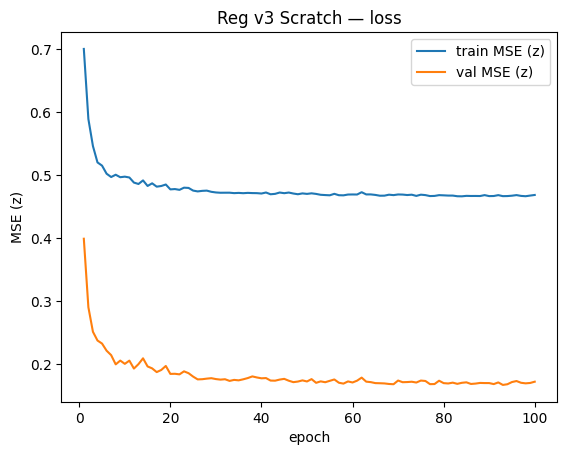

In [4]:
EPOCHS, BATCH, LR0 = 100, 64, 1e-3
history = {"epoch": [], "train_loss_z": [], "val_loss_z": [], "val_rmse": [], "lr": []}
rng = np.random.default_rng(SEED)

def mse_z(a, b):
    return float(np.mean((a - b) ** 2))

def eval_full(m):
    pz_tr = m.predict(train_ds.X)
    tr = mse_z(pz_tr.reshape(-1, 1), train_ds.y)
    pz = m.predict(test_ds.X)
    vl = mse_z(pz.reshape(-1, 1), test_ds.y)
    vr = float(np.sqrt(np.mean((z_to_raw(pz) - y_test) ** 2)))
    return tr, vl, vr

for epoch in range(1, EPOCHS + 1):
    lr = 0.5 * LR0 * (1 + np.cos(np.pi * (epoch - 1) / EPOCHS))
    for xb, yb in batch_generator(train_ds, BATCH, True, rng):
        B = len(xb)
        c = model.forward(xb, train=True)
        dpred = 2.0 * (c["out"] - yb) / B
        model.adam_step(model.backward(dpred, c, xb), lr)
    tr, vl, vr = eval_full(model)
    history["epoch"].append(epoch)
    history["train_loss_z"].append(tr)
    history["val_loss_z"].append(vl)
    history["val_rmse"].append(vr)
    history["lr"].append(lr)
    if epoch == 1 or epoch % 10 == 0 or epoch == EPOCHS:
        print(f"epoch {epoch:03d} | train_z {tr:.4f} | val_z {vl:.4f} | val_RMSE_$ {vr:.0f} | lr {lr:.2e}")

np.savez("weights_v3/regression_scratch.npz",
         W1=model.W1, b1=model.b1, g1=model.g1, s1=model.s1, rm1=model.rm1, rv1=model.rv1,
         W2=model.W2, b2=model.b2, g2=model.g2, s2=model.s2, rm2=model.rm2, rv2=model.rv2,
         W3=model.W3, b3=model.b3, mean=scaler.mean_, scale=scaler.scale_,
         columns=np.array(REG_3OF3), y_mean=np.array([Y_MEAN]), y_scale=np.array([Y_SCALE]))
pd.DataFrame(history).to_csv("weights_v3/regression_scratch_history.csv", index=False)
print("saved to weights_v3/")
plt.figure(); plt.plot(history["epoch"], history["train_loss_z"], label="train MSE (z)")
plt.plot(history["epoch"], history["val_loss_z"], label="val MSE (z)")
plt.xlabel("epoch"); plt.ylabel("MSE (z)"); plt.legend(); plt.title("Reg v3 Scratch — loss"); plt.show()

## 6. Inference Loop — fresh instance loads `./weights_v3/regression_scratch.npz`, metrics in raw $

In [5]:
z = np.load("weights_v3/regression_scratch.npz")
fresh = ScratchDeepMLP(in_dim=len(REG_3OF3), h=64, p=0.2, seed=0)
for n in ("W1", "b1", "g1", "s1", "rm1", "rv1", "W2", "b2", "g2", "s2", "rm2", "rv2", "W3", "b3"):
    setattr(fresh, n, z[n])
pred = z_to_raw(fresh.predict(test_ds.X))
test_mse = float(mean_squared_error(y_test, pred))
metrics = {
    "test_loss_MSE_raw": round(test_mse, 1),
    "rmse": round(float(np.sqrt(test_mse)), 1),
    "mae": round(float(mean_absolute_error(y_test, pred)), 1),
    "r2": round(float(r2_score(y_test, pred)), 4),
    "n_test": int(len(y_test)), "seed": SEED,
}
print(json.dumps(metrics, indent=2))
with open("weights_v3/regression_scratch_test_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
for i in range(5):
    print(f"  pred={pred[i]:.0f} true={y_test[i]:.0f}")

{
  "test_loss_MSE_raw": 116585505.8,
  "rmse": 10797.5,
  "mae": 6915.9,
  "r2": 0.7476,
  "n_test": 443,
  "seed": 42
}
  pred=70035 true=62450
  pred=35486 true=37235
  pred=70719 true=65492
  pred=37887 true=42618
  pred=40673 true=26997


## 7. Parity check — scratch v3 vs PyTorch v3 oracle

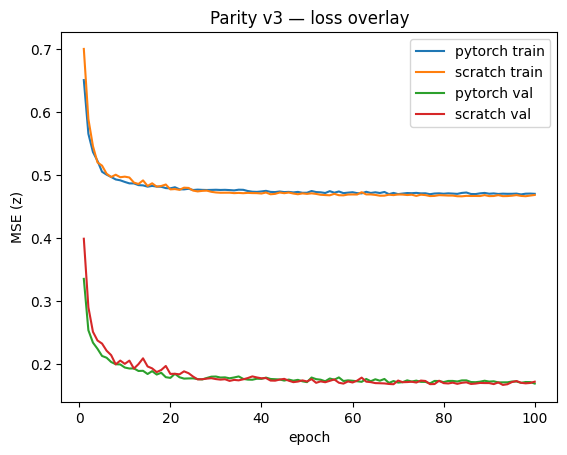

test_loss_MSE_raw 114570589.1 116585505.8  absΔ=2014916.70 relΔ=0.018
rmse                 10703.8     10797.5  absΔ=93.70 relΔ=0.009
mae                   6906.5      6915.9  absΔ=9.40 relΔ=0.001
r2                    0.7519      0.7476  absΔ=0.00 relΔ=0.006

PARITY v3: PASS


In [6]:
import os as _os
assert _os.path.exists("weights_v3/regression_pytorch_history.csv"), "run regression_pytorch_v3.ipynb first"
ph = pd.read_csv("weights_v3/regression_pytorch_history.csv")
sh = pd.read_csv("weights_v3/regression_scratch_history.csv")
plt.figure(); plt.plot(ph["epoch"], ph["train_loss_z"], label="pytorch train")
plt.plot(sh["epoch"], sh["train_loss_z"], label="scratch train")
plt.plot(ph["epoch"], ph["val_loss_z"], label="pytorch val")
plt.plot(sh["epoch"], sh["val_loss_z"], label="scratch val")
plt.xlabel("epoch"); plt.ylabel("MSE (z)"); plt.legend(); plt.title("Parity v3 — loss overlay"); plt.show()
pm = json.load(open("weights_v3/regression_pytorch_test_metrics.json"))
sm = json.load(open("weights_v3/regression_scratch_test_metrics.json"))
for k in ("test_loss_MSE_raw", "rmse", "mae", "r2"):
    d = abs(sm[k] - pm[k]); rel = d / abs(pm[k]) if pm[k] != 0 else d
    print(f"{k:<16}{pm[k]:>12}{sm[k]:>12}  absΔ={d:.2f} relΔ={rel:.3f}")
rmse_ok = abs(sm["rmse"] - pm["rmse"]) / pm["rmse"] < 0.10
r2_ok = abs(sm["r2"] - pm["r2"]) < 0.05
print("\nPARITY v3:", "PASS" if (rmse_ok and r2_ok) else "FAIL")